# **ADIDAS SALES ANALYTICS & FORECASTING**

# Data cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/Adidas sales analytics.xlsx')
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [ ]:
df.shape

(9648, 13)

In [ ]:
df.columns =  df.columns.str.lower()

In [ ]:
df.columns

Index(['retailer', 'retailer id', 'invoice date', 'region', 'state', 'city',
       'product', 'price per unit', 'units sold', 'total sales',
       'operating profit', 'operating margin', 'sales method'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['retailer', 'retailer_id', 'invoice_date', 'region', 'state', 'city',
       'product', 'price_per_unit', 'units_sold', 'total_sales',
       'operating_profit', 'operating_margin', 'sales_method'],
      dtype='object')

In [ ]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [ ]:
df['month'] = df['invoice_date'].dt.month

In [ ]:
df['month_name'] = df['invoice_date'].dt.month_name()

In [ ]:
df[['invoice_date','month','month_name']].head()

,invoice_date,month,month_name
0,2020-01-01,1,January
1,2020-01-02,1,January
2,2020-01-03,1,January
3,2020-01-04,1,January
4,2020-01-05,1,January


In [ ]:
df.describe()

,retailer_id,invoice_date,price_per_unit,units_sold,total_sales,operating_profit,operating_margin,month
count,9.648000e+03,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,2021-05-10 15:20:44.776119296,45.216625,256.930037,93273.437500,34425.244761,0.422991,6.458126
min,1.128299e+06,2020-01-01 00:00:00,7.000000,0.000000,0.000000,0.000000,0.100000,1.000000
25%,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,4254.500000,1921.752500,0.350000,3.000000
50%,1.185732e+06,2021-06-04 00:00:00,45.000000,176.000000,9576.000000,4371.420000,0.410000,6.000000
75%,1.185732e+06,2021-09-16 00:00:00,55.000000,350.000000,150000.000000,52062.500000,0.490000,9.000000
max,1.197831e+06,2021-12-31 00:00:00,110.000000,1275.000000,825000.000000,390000.000000,0.800000,12.000000
std,2.636038e+04,NaN,14.705397,214.252030,141916.016727,54193.113713,0.097197,3.454799


# **Exploratory Data Analysis (EDA)**

In [ ]:
df['region'].unique()

array(['Northeast', 'South', 'West', 'Midwest', 'Southeast'], dtype=object)

In [ ]:
df['product'].unique()

array(["Men's Street Footwear", "Men's Athletic Footwear",
       "Women's Street Footwear", "Women's Athletic Footwear",
       "Men's Apparel", "Women's Apparel"], dtype=object)

In [ ]:
df['sales_method'].unique()

array(['In-store', 'Outlet', 'Online'], dtype=object)

In [ ]:
df['region'].value_counts()

,count
region,
West,2448
Northeast,2376
Midwest,1872
South,1728
Southeast,1224


In [ ]:
df['total_sales'].sum()

np.float64(899902125.0)

In [ ]:
df.describe()

,retailer_id,invoice_date,price_per_unit,units_sold,total_sales,operating_profit,operating_margin,month
count,9.648000e+03,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,2021-05-10 15:20:44.776119296,45.216625,256.930037,93273.437500,34425.244761,0.422991,6.458126
min,1.128299e+06,2020-01-01 00:00:00,7.000000,0.000000,0.000000,0.000000,0.100000,1.000000
25%,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,4254.500000,1921.752500,0.350000,3.000000
50%,1.185732e+06,2021-06-04 00:00:00,45.000000,176.000000,9576.000000,4371.420000,0.410000,6.000000
75%,1.185732e+06,2021-09-16 00:00:00,55.000000,350.000000,150000.000000,52062.500000,0.490000,9.000000
max,1.197831e+06,2021-12-31 00:00:00,110.000000,1275.000000,825000.000000,390000.000000,0.800000,12.000000
std,2.636038e+04,NaN,14.705397,214.252030,141916.016727,54193.113713,0.097197,3.454799


In [ ]:
df['operating_profit'].sum()

np.float64(332134761.45000005)

In [ ]:
df['units_sold'].sum()

np.int64(2478861)

In [ ]:
total_revenue = df['total_sales'].sum()
total_profit = df['operating_profit'].sum()
total_units = df['units_sold'].sum()

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Units Sold:", total_units)

Total Revenue: 899902125.0
Total Profit: 332134761.45000005
Total Units Sold: 2478861


# **Revenue by Region (Bar Chart)**

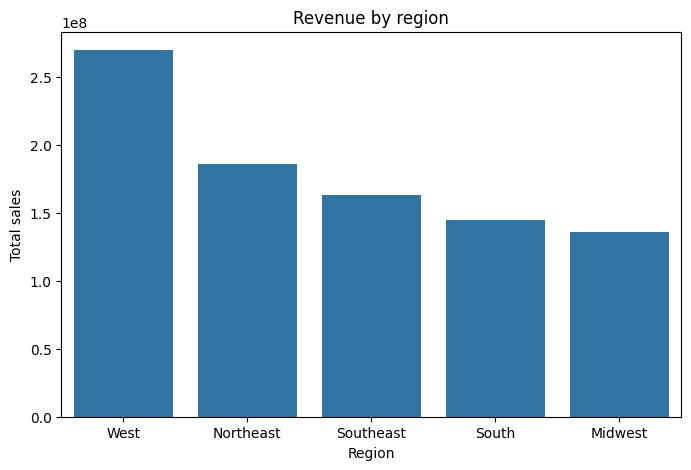

In [ ]:
region_sales = df.groupby('region')['total_sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Revenue by region")
plt.xlabel("Region")
plt.ylabel("Total sales")
plt.show()


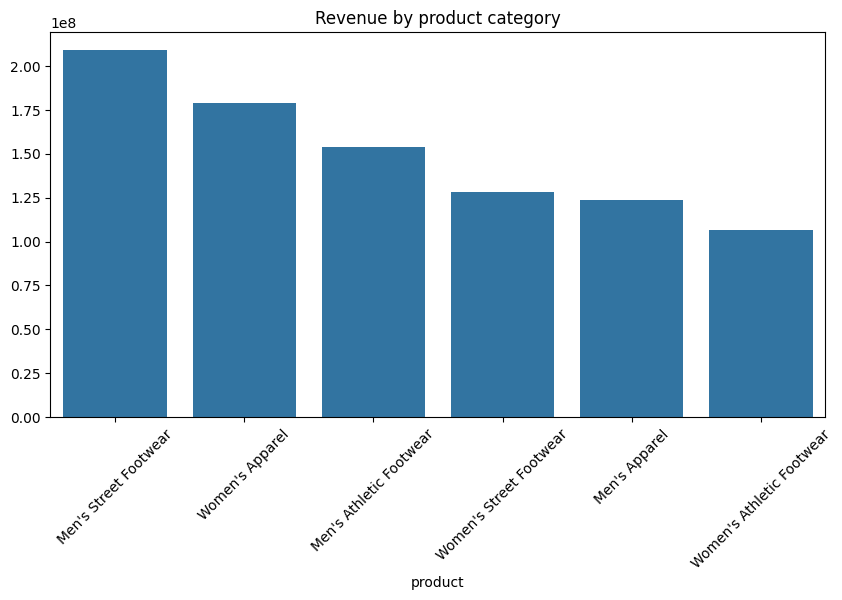

In [ ]:

product_sales = df.groupby('product')['total_sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=product_sales.index, y=product_sales.values)
plt.xticks(rotation=45)
plt.title("Revenue by product category")
plt.show()

# **Revenue by sales method**

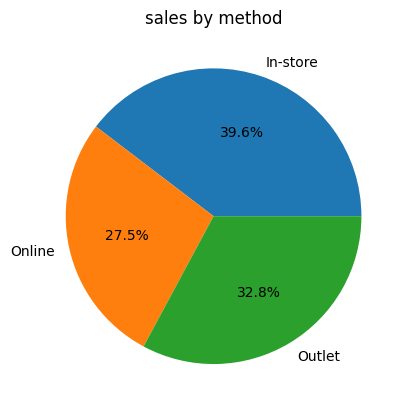

In [ ]:
method_sales =df.groupby("sales_method")["total_sales"].sum()
method_sales.plot(kind='pie', autopct ='%1.1f%%')
plt.title("sales by method")
plt.ylabel('')
plt.show()

# **Profit vs Revenue Relationship**

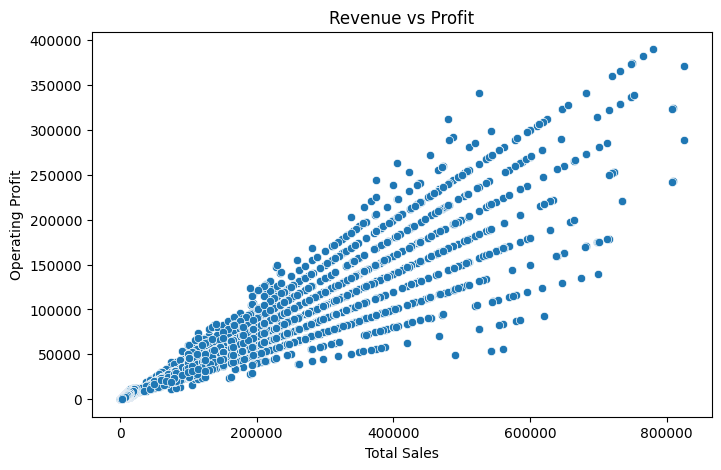

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['total_sales'], y=df['operating_profit'])
plt.title("Revenue vs Profit")
plt.xlabel("Total Sales")
plt.ylabel("Operating Profit")
plt.show()

In [ ]:
monthly_sales = df.groupby('month')['total_sales'].sum()

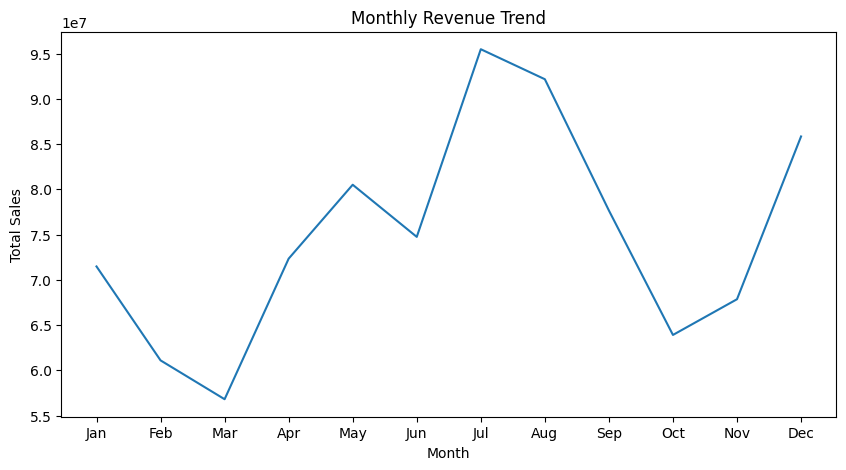

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,5))

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)

plt.xticks(ticks=range(1,13), labels=month_labels)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px

In [ ]:
state_sales = df.groupby('state')['total_sales'].sum().reset_index()
state_sales.head()

,state,total_sales
0,Alabama,17633424.0
1,Alaska,14753103.0
2,Arizona,15782221.0
3,Arkansas,12639347.0
4,California,60174133.0


In [ ]:
state_abbrev = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA",
    "Kansas":"KS","Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
    "Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
    "Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH",
    "New Jersey":"NJ","New Mexico":"NM","New York":"NY","North Carolina":"NC",
    "North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA",
    "Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD","Tennessee":"TN",
    "Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
    "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}

In [ ]:
state_sales['state_code'] = state_sales['state'].map(state_abbrev)

In [ ]:
state_sales.head()

,state,total_sales,state_code
0,Alabama,17633424.0,AL
1,Alaska,14753103.0,AK
2,Arizona,15782221.0,AZ
3,Arkansas,12639347.0,AR
4,California,60174133.0,CA


In [ ]:
state_sales['sales_millions'] = state_sales['total_sales'] / 1_000_000

In [ ]:
fig = px.choropleth(
    state_sales,
    locations='state_code',
    locationmode='USA-states',
    color='sales_millions',
    scope='usa',
    color_continuous_scale='Viridis',
    title='Adidas Sales by State'
)

fig.show()

/tmp/ipykernel_718/4273050238.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




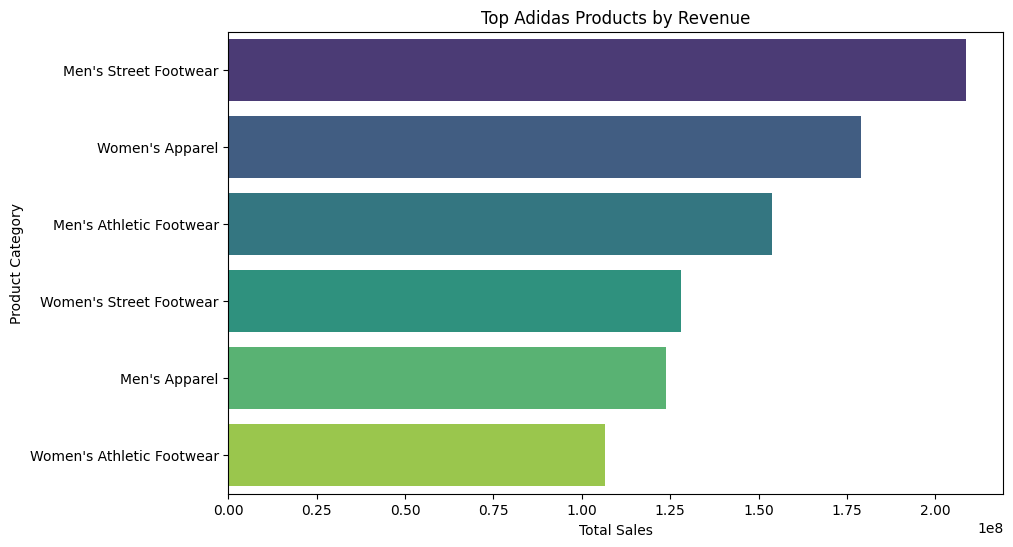

In [ ]:
product_sales = df.groupby('product')['total_sales'].sum().sort_values(ascending=False)
product_sales
plt.figure(figsize=(10,6))

sns.barplot(
    x=product_sales.values,
    y=product_sales.index,
    palette="viridis"
)

plt.title("Top Adidas Products by Revenue")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

plt.show()

In [ ]:
sales_method = df.groupby('sales_method')['total_sales'].sum()
sales_method

,total_sales
sales_method,
In-store,356643750.0
Online,247672882.0
Outlet,295585493.0


/tmp/ipykernel_718/13957748.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




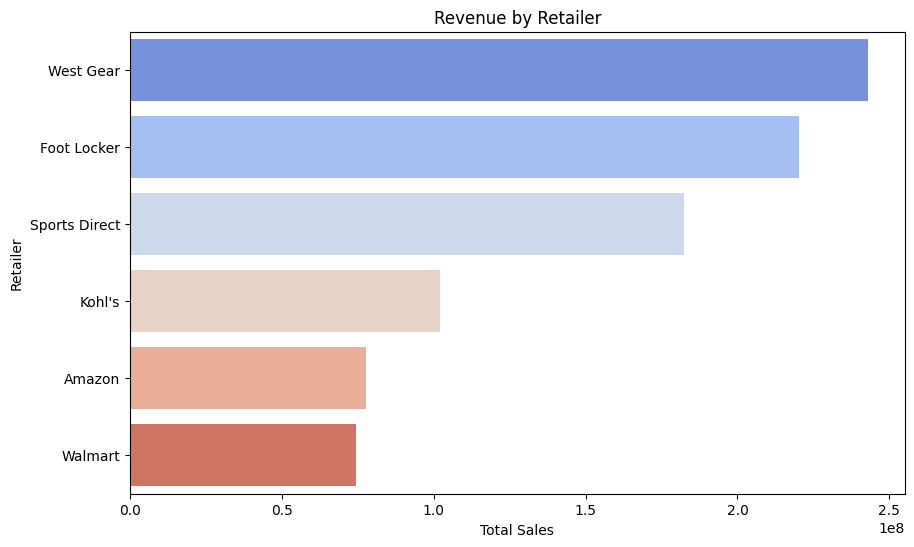

In [ ]:
retailer_sales = df.groupby('retailer')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=retailer_sales.values,
    y=retailer_sales.index,
    palette="coolwarm"
)

plt.title("Revenue by Retailer")
plt.xlabel("Total Sales")
plt.ylabel("Retailer")

plt.show()

In [ ]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [ ]:
df['year'] = df['invoice_date'].dt.year

In [ ]:
df[['invoice_date','year','month']].head()

,invoice_date,year,month
0,2020-01-01,2020,1
1,2020-01-02,2020,1
2,2020-01-03,2020,1
3,2020-01-04,2020,1
4,2020-01-05,2020,1


In [ ]:
monthly_revenue = df.groupby(['year','month'])['total_sales'].sum().reset_index()

In [ ]:
monthly_revenue.head()

,year,month,total_sales
0,2020,1,16253746.0
1,2020,2,14997988.0
2,2020,3,17660577.0
3,2020,4,24607006.0
4,2020,5,16918014.0


In [ ]:
monthly_revenue['date'] = pd.to_datetime(
    monthly_revenue[['year','month']].assign(day=1)
)

In [ ]:
monthly_revenue.head()

,year,month,total_sales,date
0,2020,1,16253746.0,2020-01-01
1,2020,2,14997988.0,2020-02-01
2,2020,3,17660577.0,2020-03-01
3,2020,4,24607006.0,2020-04-01
4,2020,5,16918014.0,2020-05-01


In [ ]:
monthly_revenue = monthly_revenue.sort_values('date')

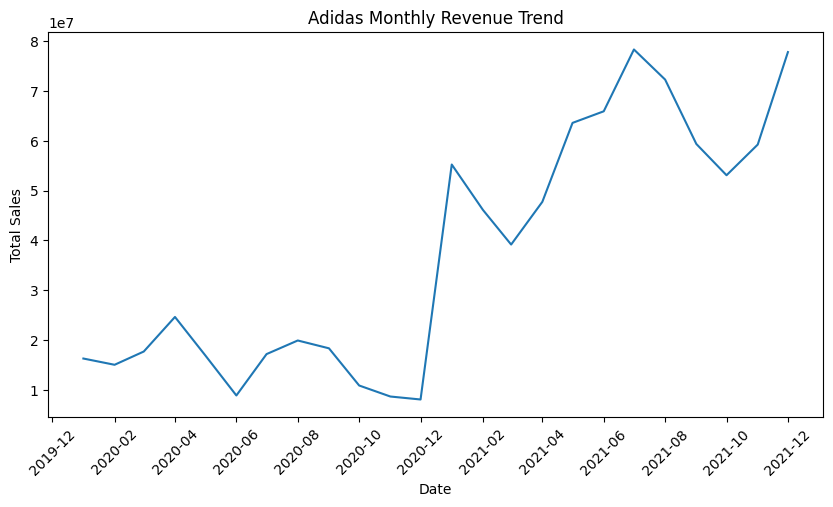

In [ ]:
import matplotlib.dates as mdates

plt.figure(figsize=(10,5))

sns.lineplot(data=monthly_revenue, x='date', y='total_sales')

plt.title("Adidas Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.show()

In [ ]:
monthly_revenue.shape

(24, 4)

# **Forecast Visualisation**

In [ ]:
ts_data = monthly_revenue.set_index('date')
ts_data.head()

,year,month,total_sales
date,,,
2020-01-01,2020,1,16253746.0
2020-02-01,2020,2,14997988.0
2020-03-01,2020,3,17660577.0
2020-04-01,2020,4,24607006.0
2020-05-01,2020,5,16918014.0


In [ ]:
sales_series = ts_data['total_sales']

In [ ]:
ts_data['time_index'] = range(len(ts_data))

In [ ]:
from sklearn.linear_model import LinearRegression

X = ts_data[['time_index']]
y = ts_data['total_sales']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
future_index = range(len(ts_data), len(ts_data) + 6)

future_df = pd.DataFrame({'time_index': future_index})

future_predictions = model.predict(future_df)
future_predictions

array([74342251.77173913, 77289958.16347826, 80237664.55521739,
       83185370.94695652, 86133077.33869565, 89080783.73043478])

In [ ]:
future_dates = pd.date_range(
    start=ts_data.index[-1] + pd.DateOffset(months=1),
    periods=6,
    freq='MS'
)

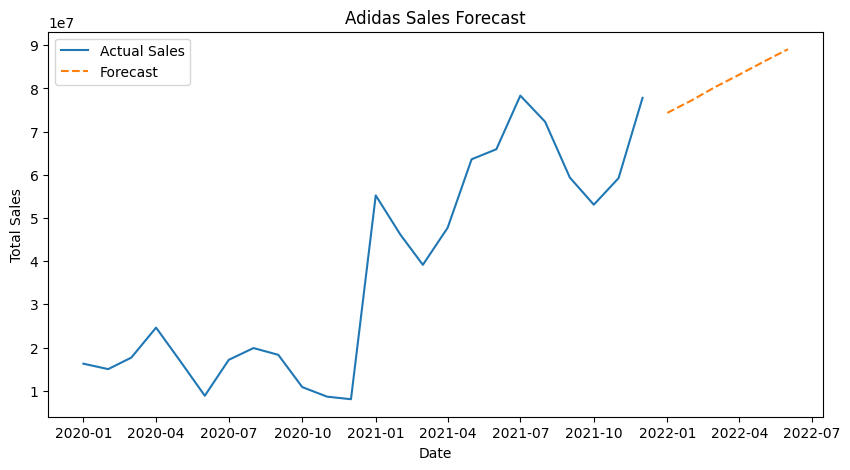

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(ts_data.index, ts_data['total_sales'], label="Actual Sales")

plt.plot(future_dates, future_predictions, linestyle="--", label="Forecast")

plt.title("Adidas Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.legend()

plt.show()

In [ ]:
df['profit_margin'] = df['operating_profit'] / df['total_sales']

In [ ]:
df['profit_margin'] = df['profit_margin'] * 100

In [ ]:
df[['total_sales','operating_profit','profit_margin']].head()

,total_sales,operating_profit,profit_margin
0,600000.0,300000.0,50.0
1,500000.0,150000.0,30.0
2,400000.0,140000.0,35.0
3,382500.0,133875.0,35.0
4,540000.0,162000.0,30.0


In [ ]:
df.to_excel("adidas_cleaned_data.xlsx", index=False)